<a href="https://colab.research.google.com/github/Whopie29/Machine_learning_concepts/blob/main/meta_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pystan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00


In [2]:
pip install prophet

In [5]:
pip install prophet

In [6]:
import pandas as pd
import prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
df=pd.read_csv('airline_passengers.csv')

In [10]:
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [11]:
df.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


<Axes: >

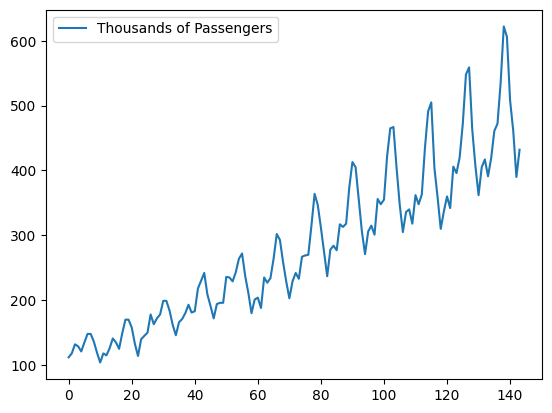

In [12]:
df.plot()

In [17]:
df.columns=['da','y']
df.head()

,da,y
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [18]:
df.drop(144,axis=0,inplace=True)

In [19]:
df.tail()

,da,y
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [22]:
df['da']=pd.to_datetime(df['da'])
df.head()

,da,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [27]:
from prophet import Prophet

In [28]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [29]:
model=Prophet()

In [30]:
df.columns

Index(['da', 'y'], dtype='object')

In [32]:
df.rename(columns={'da': 'ds'}, inplace=True)
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [38]:
#create date future of 365
future_dates=model.make_future_dataframe(periods=365)
future_dates.tail()

,ds
504,1961-11-27
505,1961-11-28
506,1961-11-29
507,1961-11-30
508,1961-12-01


In [34]:
pred=model.predict(future_dates)

In [36]:
pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406531,58.105464,114.595840,107.406531,107.406531,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,0.0,0.0,0.0,86.019134
1,1949-02-01,109.550753,52.021913,106.702438,109.550753,109.550753,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,0.0,0.0,0.0,79.495466
2,1949-03-01,111.487469,81.390921,138.621094,111.487469,111.487469,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,0.0,0.0,0.0,111.025724
3,1949-04-01,113.631691,79.714803,137.820265,113.631691,113.631691,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,0.0,0.0,0.0,108.719164
4,1949-05-01,115.706744,84.206622,142.344611,115.706744,115.706744,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,0.0,0.0,0.0,112.095464


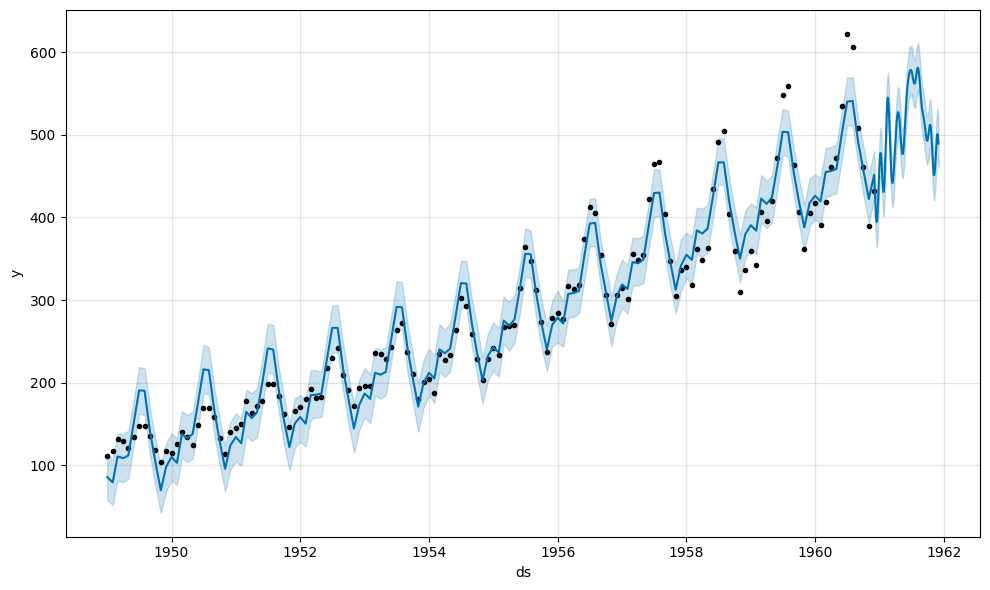

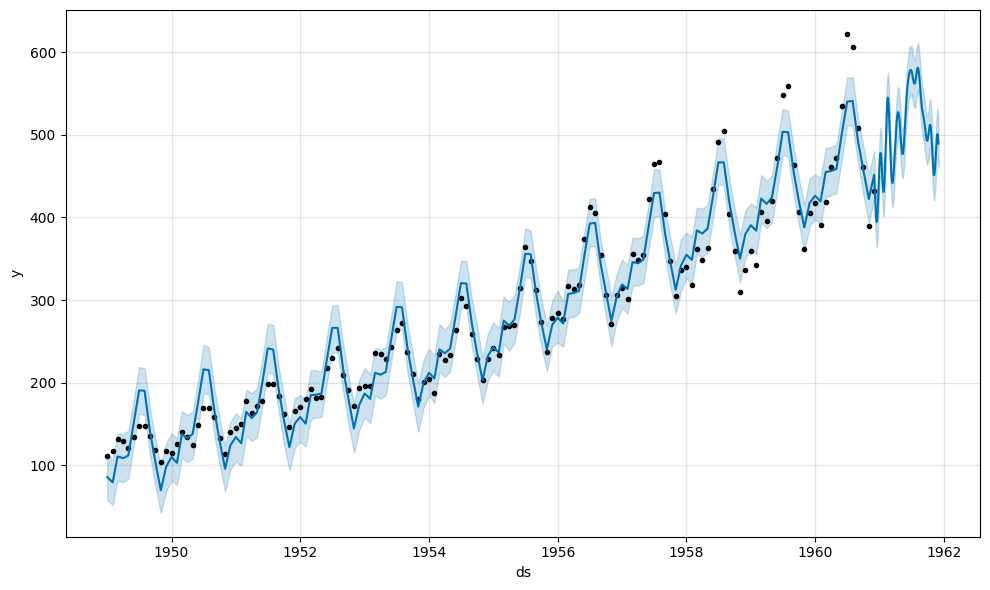

In [39]:
model.plot(pred)

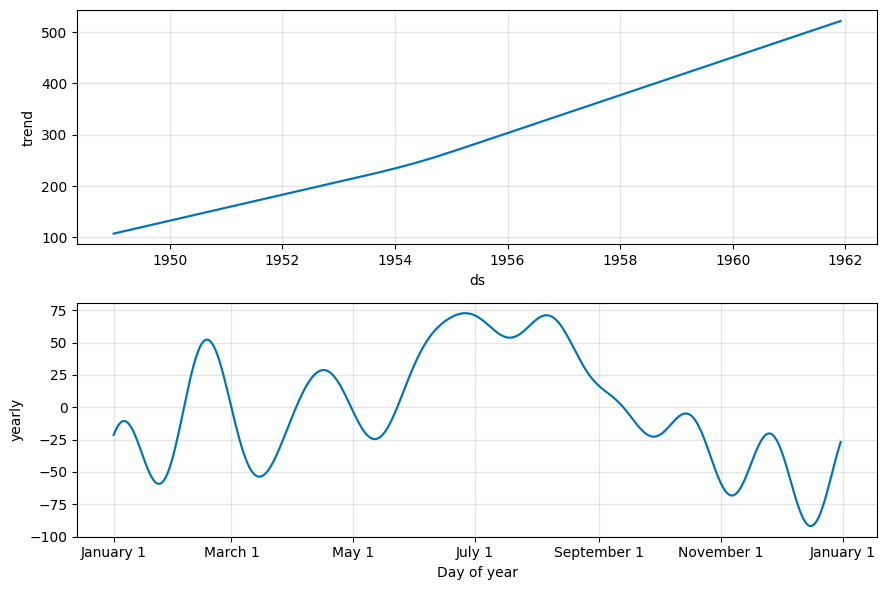

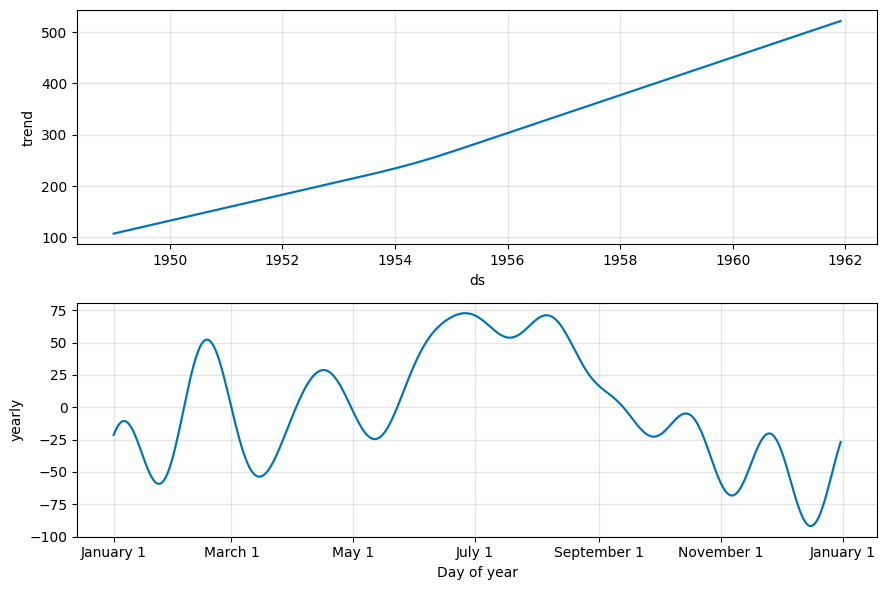

In [41]:
model.plot_components(pred)

In [43]:
# Now we have to do CROSS VALIDATION to check our model
# Lets assume we have data of 1960-1962
# cross validation will divide this dataset into 2 parts
# 1960-61 --> training dataset
# 1961-62 --> testing dataset

In [44]:
from prophet.diagnostics import cross_validation

In [45]:
df_cv=cross_validation(model,initial='730 days', period='180 days',horizon='365 days')

INFO:prophet:Making 19 forecasts with cutoffs between 1951-01-18 00:00:00 and 1959-12-02 00:00:00


  0%|          | 0/19 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [46]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,158.547167,158.298033,158.784970,150.0,1951-01-18
1,1951-03-01,171.930526,171.162889,172.711380,178.0,1951-01-18
2,1951-04-01,160.294098,158.857326,161.822914,163.0,1951-01-18
3,1951-05-01,146.088907,143.915520,148.563471,172.0,1951-01-18
4,1951-06-01,181.775447,178.820036,185.295663,178.0,1951-01-18


In [47]:
from prophet.diagnostics import performance_metrics
df_p=performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1089.756319,33.011457,25.888132,0.078584,0.073831,0.079624,0.272727
1,42 days,1015.069514,31.860156,25.207098,0.076726,0.073831,0.077409,0.227273
2,46 days,909.811604,30.163083,24.621984,0.078579,0.078887,0.078319,0.181818
3,47 days,1044.412302,32.317368,26.737303,0.081350,0.085408,0.081498,0.181818
4,48 days,1034.021370,32.156203,26.194391,0.079480,0.085408,0.079693,0.227273
